# Práctica: YOLO y visión artificial

YOLO es una herramienta muy potente para poder gestionar desde cámaras de seguridad hasta incluso partidos de fútbol, baloncesto...
En esta práctica aprenderemos a utilizar la herramienta tanto para vídeos como para imágenes.

Contenidos:
1. Mostrar boxes e identificar elementos en imágenes.
2. Gestión de elementos dentro de un vídeo.
3. Observar el movimiento de un mismo objeto en el tiempo.
4. Gestionar y dividir el vídeo en diferentes zonas.

---

## Configuración Inicial

Lo primero de todo, instalemos las librerías necesarias para poder utilizar YOLO y descargar modelos.

In [ ]:
!pip install -U ultralytics opencv-python transformers huggingface_hub yt-dlp[standard]

In [11]:
from transformers import AutoModel
from PIL import Image
from ultralytics import YOLO
from huggingface_hub import hf_hub_download
import cv2
import requests
from yt_dlp import YoutubeDL
from google.colab.patches import cv2_imshow
from IPython.display import clear_output
import os

# Ejercicio 1: Gestión de clases en YOLO

Objetivo: Detectar y clasificar el tráfico en una calle.

## Qué hay que hacer:
- Buscar un modelo de detección de tráfico
- Comprobar qué clases es capaz de detectar el modelo (qué tipos de vehículos)
- Abrir la imagen dada para procesarla y aplica el modelo
- Mostrar una imagen con todos los vehículos detectados y su tipos
- Indica cuántos objetos se han detectado de cada clase

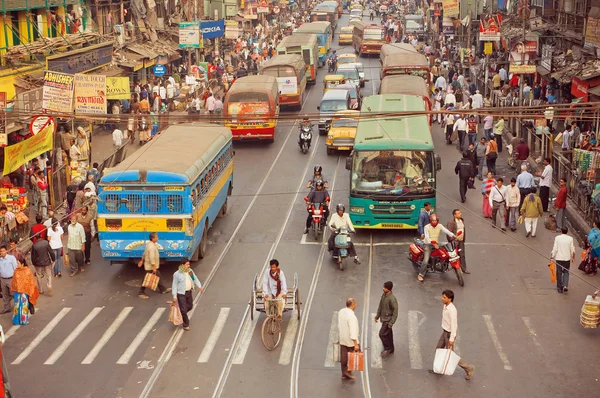

In [13]:
import urllib.request

IMG_PATH = "https://raw.githubusercontent.com/jorgecs/apuntes/main/docs/ut5_ia_aplicada/4_yolo/img/street_photo.webp"
urllib.request.urlretrieve(IMG_PATH, "street_photo.webp")

cv2_imshow(cv2.imread("street_photo.webp"))


In [ ]:
#TODO: Crea el modelo

#TODO: Predice las clases la imagen con el modelo

#TODO: Muestra la imagen con las boxes y la probabilidad

#TODO: Imprime cuántos elementos se han encontrado de cada clase

# Ejercicio 2: filtro de privacidad

En este ejercicio aprenderás a aplicar un filtro de privacidad sobre una imagen, difuminando las caras detectadas automáticamente.

Objetivo: Detectar caras en una imagen y aplicar un desenfoque (blur) sobre ellas para ocultar la identidad de las personas.

## Qué hay que hacer

1. Detectar las caras en la imagen (busca un modelo en Hugging Face específico para detección de caras).
2. Para cada cara detectada:
   - Recortar la región correspondiente `face = img[int(y1):int(y2), int(x1):int(x2)]`.
   - Aplicar un desenfoque (GaussianBlur).
   - Reemplazar esa zona en la imagen original `img[int(y1):int(y2), int(x1):int(x2)] = blur`.
3. Mostrar la imagen final con las caras difuminadas.

`img[y1:y2, x1:x2]` permite acceder a una parte de la imagen (recorte).
Al asignar sobre esa misma zona, estamos modificando la imagen original.


Para aplicar blur en OpenCV:
```python
blur = cv2.GaussianBlur(face, (25, 25), 0)

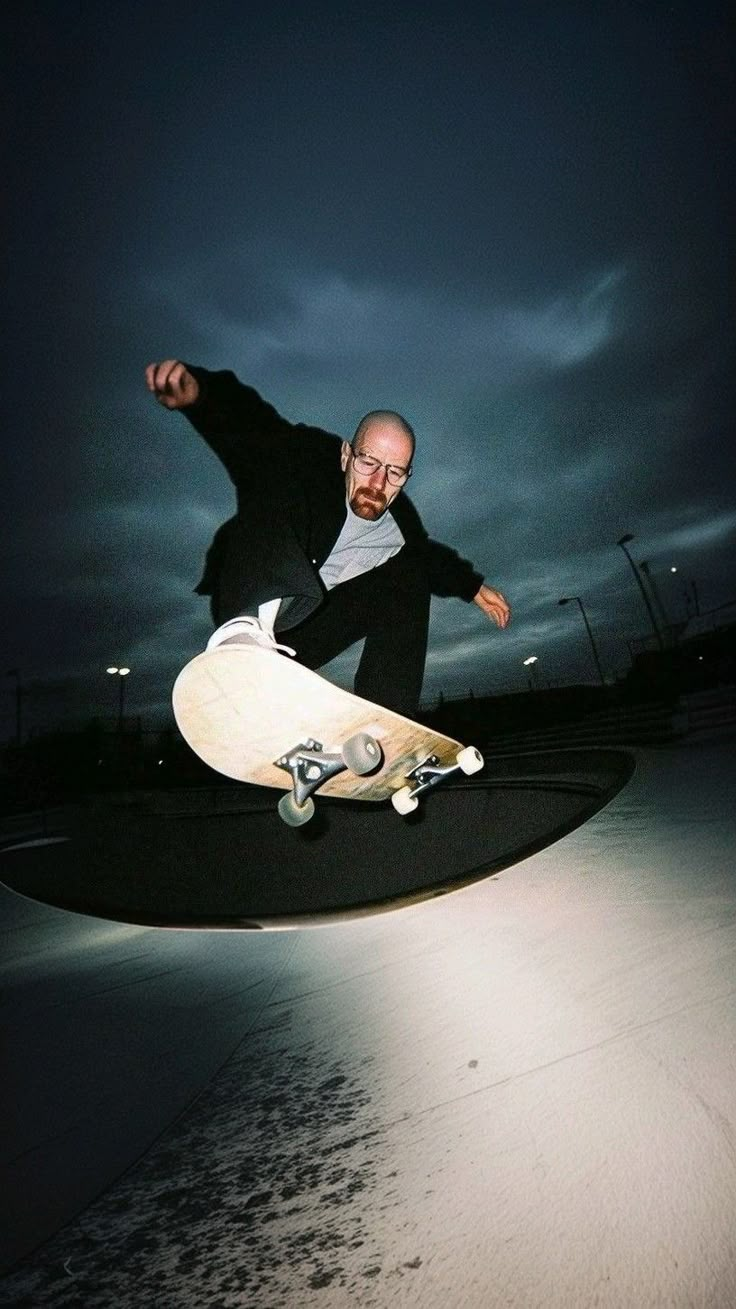

In [ ]:
IMG_PATH_BLUR = "https://raw.githubusercontent.com/jorgecs/apuntes/main/docs/ut5_ia_aplicada/4_yolo/img/blur.jpg"
urllib.request.urlretrieve(IMG_PATH_BLUR, "blur_photo.png")

cv2_imshow(cv2.imread("blur_photo.png"))

In [ ]:
img = cv2.imread("blur_photo.jpg")

#TODO: Busca el modelo para detección de caras, realiza la predicción con el modelo entrenado, mira las detecciones y difumina las partes de la imagen donde se han encontrado caras

model_path_blur = hf_hub_download(
    repo_id="",
    filename=""
)

model_blur = YOLO(model_path_blur)

# Ejercicio 3: detección de personas con YOLO

Objetivo: usar un modelo YOLO para detectar personas en un vídeo y obtener el **máximo número de personas que se han visto a la vez**.

A continuación se descargará el vídeo con las personas a detectar y se recortará para que solamente ocupe lo necesario.

In [ ]:
url = "https://www.youtube.com/watch?v=vJG698U2Mvo"

ydl_opts = {
    "format": "bv*[vcodec^=avc1]+ba/b[ext=mp4]",
    "outtmpl": "/content/full_video.%(ext)s",
    "merge_output_format": "mp4",
}


with YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

VIDEO_PATH = "/content/selective_attention.mp4"


In [ ]:
!ffmpeg -ss 00:12 -to 01:02 -i /content/full_video.mp4 -c copy /content/selective_attention.mp4 -y

## Qué hay que hacer

1. Usa un modelo de Ultralytics YOLO para detección de objetos. Puedes usar yolov8n.pt (modelo base) o buscar un modelo en Hugging Face.
2. Si usas un modelo de Hugging Face, cárgalo con `hf_hub_download`. Si usas el modelo base de YOLO, con `ultralytics`.
3. Abre el vídeo para procesarlo.
4. Obtén el máximo de personas visibles en el vídeo.

IMPORTANTE: Hay que filtrar la clase `person`

Acuérdate de que puedes mostrar los frames con:
```python
clear_output(wait=True)
cv2.imshow("Detecciones en tiempo real", frame)
```

In [ ]:
# TODO: Implementa el ejercicio 2 aquí

# Ejercicio 4: Usando tracking

Objetivo: ¿Hacia dónde se mueve una persona en un vídeo?

En el ejercicio anterior contábamos el máximo de personas por frame. Pero si una persona sale y entra o si queremos saber el la dirección, necesitamos **Tracking**.

El **tracking** añade un identificador (ID) a cada objeto para seguirlo en el tiempo, así podemos saber qué bounding box corresponde a qué elemento en todo momento.

El problema que puede tener es que si YOLO pierde de vista un objeto y lo vuelve a ver, puede asignarle un nuevo ID.

### Ejemplo de tracking

```python
from ultralytics import YOLO
import cv2

model = YOLO("yolov8n.pt")

#Abrimos el video con OpenCV para iterar frame a frame, como siempre
cap = cv2.VideoCapture("video.mp4")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    #En lugar de usar predict, usamos track, que nos devuelve un resultado similar pero con información de tracking (IDs asignados a cada objeto)
    results = model.track(frame, persist=True)[0]  #El parámetro persist=True hace que el modelo intente mantener el mismo ID para cada objeto a lo largo de los frames
    
    detecciones = results.boxes

    for box in detecciones:
        track_id = int(box.id[0])  #A cada detección se le asigna un ID por el tracker, que se puede acceder con box.id[0]

cap.release()
```

Vamos a usar un vídeo capturado de una CCTV donde aparece una persona, hay que comprobar en qué dirección se ha ido esa persona tras finalizar el vídeo.

### Primero se descargará el vídeo para poder utilizarlo

In [ ]:
url_tracking = "https://www.youtube.com/watch?v=kG7d_4LeP48"

ydl_opts = {
    "format": "bv*[vcodec^=avc1]+ba/b[ext=mp4]",
    "outtmpl": "/content/full_video_tracking.%(ext)s",
    "merge_output_format": "mp4",
}


with YoutubeDL(ydl_opts) as ydl:
    ydl.download([url_tracking])

VIDEO_PATH_TRACKING = "/content/full_video_tracking.mp4"



### Qué hay que hacer:

- Utiliza `model.track(..., persist=True)` en lugar de `.predict()`.
- Los resultados ahora tendrán un campo `id` asociado (tracking ID), recuerda hacer int(...) para tener un valor numérico del ID.
- Filtra la clase person si el modelo detecta más objetos.
- Añade en un diccionario `trayectorias` el tracking ID y un array con la posición x (ya sea x1 o x2, da igual) de esa persona en cada frame.
- Comprueba hacia donde se va la persona al final del vídeo (cómo se mueve la x, si va aumentando o disminuyendo en el tiempo).

In [ ]:
#TODO: Implementa el tracking aquí usando el vídeo y un modelo de detección de personas (ya sea YOLO base o cualquier otro)

trayectorias = {}

El siguiente código permite ver cómo se ha movido la persona en la cámara frame a frame.

In [ ]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(VIDEO_PATH_TRACKING)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
cap.release()

plt.figure(figsize=(6, 10))

#trayectorias debería ser un diccionario tipo {id1: [x_1, x_2, ...], id2: [x_1, x_2, ...], ...}
for track_id, x_positions in trayectorias.items():

    if len(x_positions) < 2:
        continue

    x_norm = [x / width for x in x_positions]

    y_frames = list(range(len(x_positions)))  #eje vertical para el tiempo

    plt.plot(x_norm, y_frames, alpha=0.7)

plt.axvline(0.5, linestyle="--", color="gray")

plt.xlabel("Posición horizontal (0=izq, 1=der)")
plt.ylabel("Frames (tiempo)")
plt.title("Movimiento vertical (tiempo hacia abajo)")
plt.xlim(0, 1)

plt.gca().invert_yaxis()  #hace que el tiempo vaya de arriba a abajo

plt.show()

# Ejercicio 5: Detectar vehículos en zonas

En este ejercicio veremos cómo detectar si ciertos objetos entran en una zona definida por un ROI, usando una línea virtual. En específico, contaremos cuántos coches pasan por un paso de peatones.

##  ¿Qué es un ROI?
Un ROI (Region of Interest) es una zona de la imagen que nos interesa analizar.
En lugar de procesar toda la imagen, definimos una región concreta (por ejemplo, una calle, un paso de peatones o una zona prohibida).

Esto permite:
- Reducir ruido
- Centrar el análisis
- Simplificar la lógica del problema
Ejemplo: solo nos interesa detectar vehículos en la parte inferior de la imagen.

## ¿Qué es una línea virtual?
Una línea virtual es una línea dibujada sobre la imagen (no existe físicamente), que usamos como sensor.

Sirve para detectar eventos como:
- Un coche que cruza una calle
- Una persona que entra en una zona
- Un objeto que pasa de una región a otra

Ejemplo típico:
Si el centro del objeto cruza la línea -> evento detectado

Todo esto suele utilizarse junto a tracking, para saber qué objeto es el que ha entrado en la zona concreta.

Problemas que podemos encontrarnos:
- Líneas con pendiente
- ROI con formas diferentes a rectángulos
Hay que usar fórmulas más avanzadas para detectar en qué zona de la línea está

Por eso, nos vamos a centrar en una línea vertical completamente y un rectángulo.
### Qué hay que hacer
- Añadir las coordenadas de la zona del ROI (para no tener buscar manualmente, las coordenadas son: `X1:520 Y1:0 X2:690 Y2:1920`) 
- Añadir las coordenadas de la línea (para no tener que buscar los puntos manualmente, `Y=590`)
- Gestionar únicamente aquellos vehículos que estén en el ROI, usando el centro del bounding box -> `x=(x1+x2)/2 y=(y1+y2)/2` y comprobando que este centro esté dentro de `ROI_X1 < x < ROI_X2 ROI_Y1 < y < ROI_Y2`
- Si está en el ROI, almacena la coordenada Y de todos los vehículos en cada frame (como hacías en el ejercicio anterior).
- Cuando un vehículo haya atravesado la línea, comprueba que no lo haya hecho ya (evitar duplicados) y suma 1 a un contador.
    - Para detectar si ha atravesado la línea, por cada vehículo, comprueba su Y actual `trayectorias[track_id][-1]` y su Y del frame anterior `trayectorias[track_id][-2]`. 
        - Si antes estaba por encima de la línea `y_prev < LINE_Y` y ahora está por debajo `y_actual >= LINE_Y` → ha cruzado
        - Si antes estaba por debajo `y_prev > LINE_Y` y ahora está por encima `y_actual <= LINE_Y` → ha cruzado

### Visualización de ROI, línea y contador
Para visualizar todo esto, se puede usar OpenCV como usamos para las bounding boxes:
- Puedes mostrar el ROI  así: `cv2.rectangle(frame, (ROI_X1, ROI_Y1), (ROI_X2, ROI_Y2), (255, 0, 0), 2)`
- Puedes mostrar la línea así: `cv2.line(frame, (0, LINE_Y), (frame.shape[1], LINE_Y), (0, 0, 255), 2)`
- Puedes mostrar un contador en pantalla con: `cv2.putText(frame, f"Count: {contador}", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)`

In [ ]:
VIDEO_PATH_ROI = "https://raw.githubusercontent.com/jorgecs/apuntes/main/docs/ut5_ia_aplicada/4_yolo/img/paso_peatones.mp4"

model_path_aerial = hf_hub_download(repo_id="kilanisainikhil/AerialEye", filename="aerialEye.pt")

model = YOLO(model_path_aerial)

cap = cv2.VideoCapture(VIDEO_PATH_ROI)

#TODO: Implementa el ejercicio de conteo con ROI aquí, muy similar al ejercicio de tracking pero gestionando que estén dentro del ROI y contando cuando atraviesen la línea